# 1. Data Loading and Preprocessing
In this section, we import the essential libraries, download the dataset from Kaggle, and load the images along with their labels. The images are resized and normalized to a scale of `[0, 1]` to help the neural network converge faster during training.

In [ ]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset


path = kagglehub.dataset_download("mohammad2012191/q2-ka-ai-2026")
print("Path to dataset files:", path)

labels_df = pd.read_csv(os.path.join(path, "labels.csv"))
img_dir = os.path.join(path, "images")

images, ages = [], []

print("Loading and normalizing images...")
for index, row in labels_df.iterrows():
    img_name, age = row.iloc[0], row.iloc[1]
    img_path = os.path.join(img_dir, img_name)
    
    if os.path.exists(img_path):
        img = Image.open(img_path).convert('RGB')
        # Normalize pixel values to [0, 1]
        img_array = np.array(img) / 255.0 
        images.append(img_array)
        ages.append(age)

X = np.array(images)
y = np.array(ages)

#(Batch, Channels, Height, Width)
X = np.transpose(X, (0, 3, 1, 2))

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}   | y_test shape: {y_test.shape}")

Path to dataset files: C:\Users\resod\.cache\kagglehub\datasets\mohammad2012191\q2-ka-ai-2026\versions\1
Loading and normalizing images...
X_train shape: (1600, 3, 36, 36) | y_train shape: (1600,)
X_test shape: (400, 3, 36, 36)   | y_test shape: (400,)


# 2. PyTorch Data Preparation
Here, we convert our Numpy arrays into PyTorch Tensors. We then wrap them in `TensorDataset` and create `DataLoader` objects. This allows us to efficiently feed the data into our model in batches of 32 during the training process.

In [ ]:
# Convert Numpy arrays to PyTorch Tensors i had to use clone().detach() to avoid warnings
X_train_t = torch.tensor(X_train, dtype=torch.float32).clone().detach()
X_test_t  = torch.tensor(X_test, dtype=torch.float32).clone().detach()
y_train_t = torch.tensor(y_train, dtype=torch.float32).clone().detach()
y_test_t  = torch.tensor(y_test, dtype=torch.float32).clone().detach()

# Create TensorDatasets
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# Create DataLoaders (Batch size = 32)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 3. Model Architecture: Baseline Linear Network
We define a simple Fully Connected Neural Network (Multi-Layer Perceptron) as our baseline model. 
It consists of 4 linear layers with `ReLU` activation functions. 
*Note: Since predicting age is a regression task, the final output layer has a single node and does not use an activation function, The model is not perfict:<.*

In [ ]:
#The next step is cnn but i still trying

class AgePredictorNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(AgePredictorNN, self).__init__()
        # 4 Linear layers
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.layer3 = nn.Linear(hidden_dim, hidden_dim)
        self.layer4 = nn.Linear(hidden_dim, output_dim) # Output layer maps to a single value
        
        self.relu = nn.ReLU()

    def forward(self, x):
        # Flatten the input image: (Batch, Channels, Height, Width) -> (Batch, Features)
        x = x.view(x.size(0), -1) 
        
        a1 = self.relu(self.layer1(x))
        a2 = self.relu(self.layer2(a1))
        a3 = self.relu(self.layer3(a2))
        
        # No activation function at the end because this is a regression task
        out = self.layer4(a3)
        return out.squeeze()

# 4. Training and Validation Functions
We define two helper functions: `train_one_epoch` and `validate`. 
These functions handle the forward pass, calculate the Mean Squared Error (MSE) loss, and perform backpropagation to update the model's weights using the optimizer.

In [11]:
def train_one_epoch(model, optimizer, criterion, train_loader, device):
    model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        # Backward pass & optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    return running_loss / len(train_loader)

def validate(model, criterion, test_loader, device):
    model.eval()
    running_loss = 0.0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item()
            
    return running_loss / len(test_loader)

# 5. Model Initialization and Training Execution
We set up our device (GPU if available), initialize the model, define the MSE loss function, and use the `AdamW` optimizer. The model is then trained for 40 epochs, and we track the loss for both the training and validation sets to monitor its learning progress.

In [ ]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
input_dim = 3 * 36 * 36 
hidden_dim = 128
output_dim = 1
learning_rate = 0.001
num_epochs = 40

# Initialize model, loss function, and optimizer
model = AgePredictorNN(input_dim, hidden_dim, output_dim).to(device)
criterion = nn.MSELoss()
optimizer = AdamW(model.parameters(), lr=learning_rate)

train_losses, val_losses = [], []

print("Starting Training...")
for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, optimizer, criterion, train_loader, device)
    val_loss = validate(model, criterion, test_loader, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

print('Training Complete!')

Starting Training...
Epoch [1/40], Train Loss: 711.6233, Val Loss: 593.1881
Epoch [2/40], Train Loss: 495.9824, Val Loss: 555.2012
Epoch [3/40], Train Loss: 462.0423, Val Loss: 480.5399
Epoch [4/40], Train Loss: 404.2938, Val Loss: 398.1145
Epoch [5/40], Train Loss: 339.0940, Val Loss: 326.4489
Epoch [6/40], Train Loss: 323.7516, Val Loss: 353.6473
Epoch [7/40], Train Loss: 298.2464, Val Loss: 301.5278
Epoch [8/40], Train Loss: 266.8671, Val Loss: 272.0462
Epoch [9/40], Train Loss: 249.5173, Val Loss: 254.6836
Epoch [10/40], Train Loss: 259.2915, Val Loss: 316.1843
Epoch [11/40], Train Loss: 231.3557, Val Loss: 270.0063
Epoch [12/40], Train Loss: 221.6786, Val Loss: 239.9722
Epoch [13/40], Train Loss: 210.3546, Val Loss: 248.9441
Epoch [14/40], Train Loss: 208.6384, Val Loss: 218.1993
Epoch [15/40], Train Loss: 194.4186, Val Loss: 218.5484
Epoch [16/40], Train Loss: 182.9040, Val Loss: 226.5983
Epoch [17/40], Train Loss: 192.9508, Val Loss: 283.1585
Epoch [18/40], Train Loss: 177.4013,

# 6. Results, Visualizations & Error Analysis
In this final section, we plot the loss curves to evaluate the training process and visualize some sample predictions alongside their actual images.

### 🔍 Error Analysis (Baseline Limitations)
As observed in the visual predictions, the baseline model struggles to accurately predict ages. This is expected because we are using a standard Linear Network, which requires flattening the 2D images into 1D vectors. By flattening the images, the model loses crucial **spatial features** and structural details of the face (e.g., eye shape, wrinkles, facial proportions). 

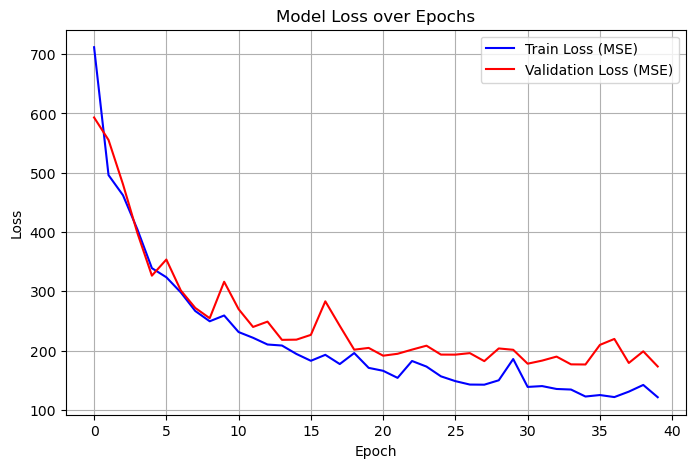

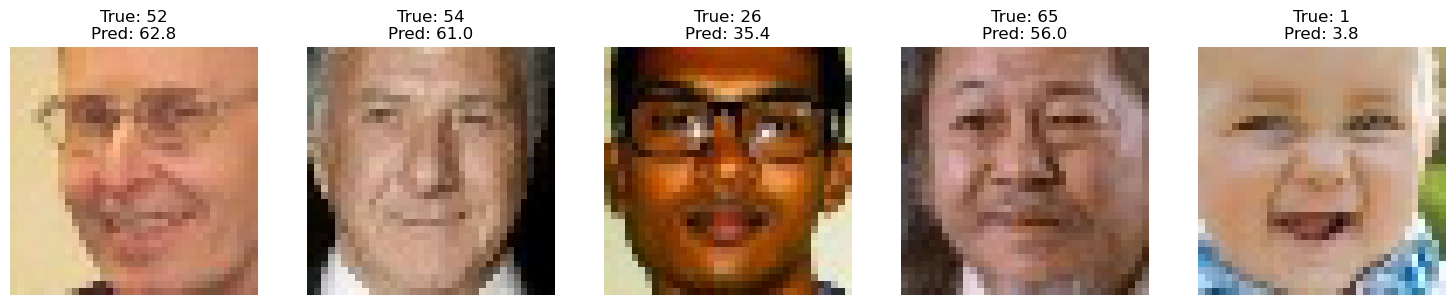

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss (MSE)', color='blue')
plt.plot(val_losses, label='Validation Loss (MSE)', color='red')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


model.eval()
X_sample, y_sample = next(iter(test_loader))
X_sample_device = X_sample.to(device)

with torch.no_grad():
    predictions = model(X_sample_device).cpu().numpy()

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = X_sample[i].permute(1, 2, 0).numpy() 
    actual_age = y_sample[i].item()
    predicted_age = predictions[i]
    
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"True: {actual_age:.0f}\nPred: {predicted_age:.1f}")

plt.tight_layout()
plt.show()